In [ ]:
# do 2D version of simplified and GPU friendly code from end of 1_oned_basis.ipynb
import numpy as np
import matplotlib.pyplot as plt

N = 50
u, v = np.linspace(0.0, 1.0, N), np.linspace(0.0, 1.0, N)
U, V = np.meshgrid(u, v)

def twod_basis(nxe, nye):

    p = 2 # 2nd order elements
    nnx = nxe + p
    nny = nye + p
    nelems = nxe * nye
    nnodes = nnx * nny

    GLOB_BASES = np.zeros((nnodes, N, N))

    elem_conn = []
    for ielem in range(nelems):
        ixe = ielem % nxe; iye = ielem // nxe
        loc_conn = []
        for i2 in range((p+1)**2):
            i = i2 % (p+1); j = i2 // (p+1)
            gx = ixe + i
            gy = iye + j
            inode = nnx * gy + gx
            loc_conn += [inode]
        elem_conn += [loc_conn]
    # print(F"{elem_conn=}")


    x_knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
    y_knots = [0.0]*(p+1) + [i/nye for i in range(1,nye)] + [1.0]*(p+1)

    def quad_bernstein(xi):
        N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
        # dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
        # return N, dN
        return N

    def get_1d_basis(xi, bndry_span):
        assert len(bndry_span) == 4
        B = quad_bernstein(xi)
        left_bndry = abs(bndry_span[0] - bndry_span[1]) < 1e-12
        right_bndry = abs(bndry_span[2] - bndry_span[3]) < 1e-12
        N = np.zeros_like(B)
        N[0] = (1.0 if left_bndry else 0.5) * B[0]
        N[2] = (1.0 if right_bndry else 0.5) * B[2]
        N[1] = B[1]
        N[1] += (0.0 if left_bndry else 0.5) * B[0]
        N[1] += (0.0 if right_bndry else 0.5) * B[2]
        return N

    def get_2d_basis(XI, ETA, x_bndry_span, y_bndry_span):
        Nx = get_1d_basis(XI, x_bndry_span)
        Ny = get_1d_basis(ETA, y_bndry_span)
        # N2 = np.outer(Nx, Ny)
        N2 = np.zeros(((p+1)**2, XI.shape[0], XI.shape[1]))
        for i2 in range((p+1)**2):
            i = i2 % (p+1); j = i2 // (p+1)
            N2[i2] = Nx[i] * Ny[j]
        return N2

    nelems = nxe * nye
    # for ielem in range(1): # DEBUG
    for ielem in range(nelems):
        ixe = ielem % nxe; iye = ielem // nxe
        x_span = x_knots[(p+ixe):(p+ixe+2)]
        y_span = y_knots[(p+iye):(p+iye+2)]
        # print(f'{x_span=} {y_span=}')

        # compute normalized coordinates inside the 2x2 element span
        XI = (U - x_span[0]) / np.diff(x_span)[0]
        ETA = (V - y_span[0]) / np.diff(y_span)[0]

        # compute xi and eta masks
        XI_MASK = np.logical_and(U >= x_span[0], U <= x_span[1])
        ETA_MASK = np.logical_and(V >= y_span[0], V <= y_span[1])

        # get surrounding knots for boundary check
        x_bndry_span = x_knots[(p+ixe-1):(p+ixe+3)]
        y_bndry_span = y_knots[(p+iye-1):(p+iye+3)]

        # compute 2d bernstein basis
        N2 = get_2d_basis(XI, ETA, x_bndry_span, y_bndry_span)
        loc_conn = elem_conn[ielem]
        # print(f"{loc_conn=}")
        for loc_node, glob_node in enumerate(loc_conn):
            GLOB_BASES[glob_node] += N2[loc_node] * XI_MASK * ETA_MASK
    
    return GLOB_BASES


<Figure size 1400x1400 with 0 Axes>

<Figure size 1400x1400 with 0 Axes>

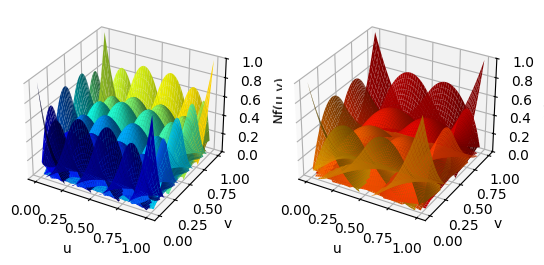

In [8]:
# plot bases transfer

fine_basis = twod_basis(4, 4)
coarse_basis = twod_basis(2, 2)

nnodes_fine = fine_basis.shape[0]
nnodes_coarse = coarse_basis.shape[0]

# PLOT SURFACE BASIS FUNCTIONS!
# =====================
fig = plt.figure()
ax = fig.add_subplot(1, 2, 1, projection='3d')

cmap = plt.cm.jet
colors = cmap(np.linspace(0, 1, nnodes_fine + nnodes_coarse))  # one color per basis

# for inode in range(nnodes):
for inode in range(nnodes_fine-1, -1, -1):
    Z = fine_basis[inode]
    Z[Z < 0.01 * Z.max()] = np.nan

    ax.plot_surface(
        U, V, Z,
        color=colors[inode],   # solid color from jet
        # alpha=0.35,
        # alpha=0.6,
        # alpha=0.8,
        alpha=1.0,
        # linewidth=0,
        linewidth=0.5,
        antialiased=True
    )

ax.set_zlim(0.0, 1.0)
ax.set_xlabel('u')
ax.set_ylabel('v')
ax.set_zlabel('Nf(u,v)')

# plot coarser basis
ax = fig.add_subplot(1, 2, 2, projection='3d')

# for inode in range(nnodes):
for inode in range(nnodes_coarse-1, -1, -1):
    Z = coarse_basis[inode]
    Z[Z < 0.01 * Z.max()] = np.nan

    ax.plot_surface(
        U, V, Z,
        color=colors[nnodes_fine+inode],   # solid color from jet
        # alpha=0.35,
        # alpha=0.6,
        # alpha=0.8,
        alpha=1.0,
        # linewidth=0,
        linewidth=0.5,
        antialiased=True
    )

ax.set_zlim(0.0, 1.0)
ax.set_xlabel('u')
ax.set_ylabel('v')
ax.set_zlabel('Nc(u,v)')

plt.show()

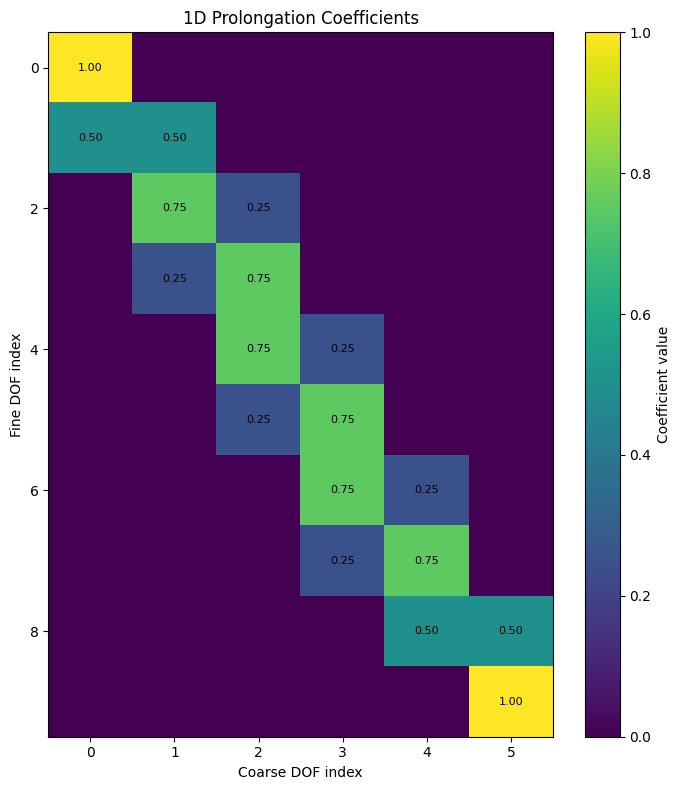

In [9]:
# first build the 1d multigrid prolongation / restriction operator


# nxe_f = 2
nxe_f = 8
# nxe_f = 16

p = 2
nxe_c = nxe_f // 2
n_fine = nxe_f + p
n_coarse = nxe_c + p

# ===============================================
# now try to reconstruct fine basis from this
# ===============================================

# restriction operator or P^T global
R = np.zeros((n_coarse, n_fine))
counts = 1e-14 * np.ones((n_coarse, n_fine))

for ielem_c in range(nxe_c):
    # left half elem
    left_felem = 2 * ielem_c
    l_mat = np.array([
        [0.75, 0.25, 0.0],
        [0.25, 0.75, 0.75],
        [0.0, 0.0, 0.25],
    ])
    if ielem_c == 0:
        l_mat[0,:2] = np.array([1.0, 0.5])
        l_mat[1,:2] = np.array([0.0, 0.5])
    if ielem_c == nxe_c - 1:
        l_mat[1, 2] = 0.5
        l_mat[2, 2] = 0.5

    # print(F"{l_mat=} {l_mat.shape=}")

    l_nz_mat = l_mat / (l_mat + 1e-14)
    R[ielem_c:(ielem_c+3), left_felem:(left_felem+3)] += l_mat
    counts[ielem_c:(ielem_c+3), left_felem:(left_felem+3)] += l_nz_mat

    # right half elem
    right_felem = 2 * ielem_c + 1
    r_mat = np.array([
        [0.25, 0.0, 0.0],
        [0.75, 0.75, 0.25],
        [0.0, 0.25, 0.75],
    ])
    if ielem_c == 0:
        r_mat[0,0] = 0.5
        r_mat[1,0] = 0.5
    if ielem_c == nxe_c - 1:
        r_mat[1, 1:] = np.array([0.5, 0.0])
        r_mat[2, 1:] = np.array([0.5, 1.0])
    r_nz_mat = r_mat / (r_mat + 1e-14)
    R[ielem_c:(ielem_c+3), right_felem:(right_felem+3)] += r_mat
    counts[ielem_c:(ielem_c+3), right_felem:(right_felem+3)] += r_nz_mat

# normalize it by weights added into each spot?
R /= counts


plt.figure(figsize=(7, 8))
plt.imshow(R.T, aspect="auto")
plt.colorbar(label="Coefficient value")
plt.xlabel("Coarse DOF index")
plt.ylabel("Fine DOF index")
plt.title("1D Prolongation Coefficients")

for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        if abs(R[i, j]) > 1e-12:
            plt.text(i, j, f"{R[i, j]:.2f}",
                     ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

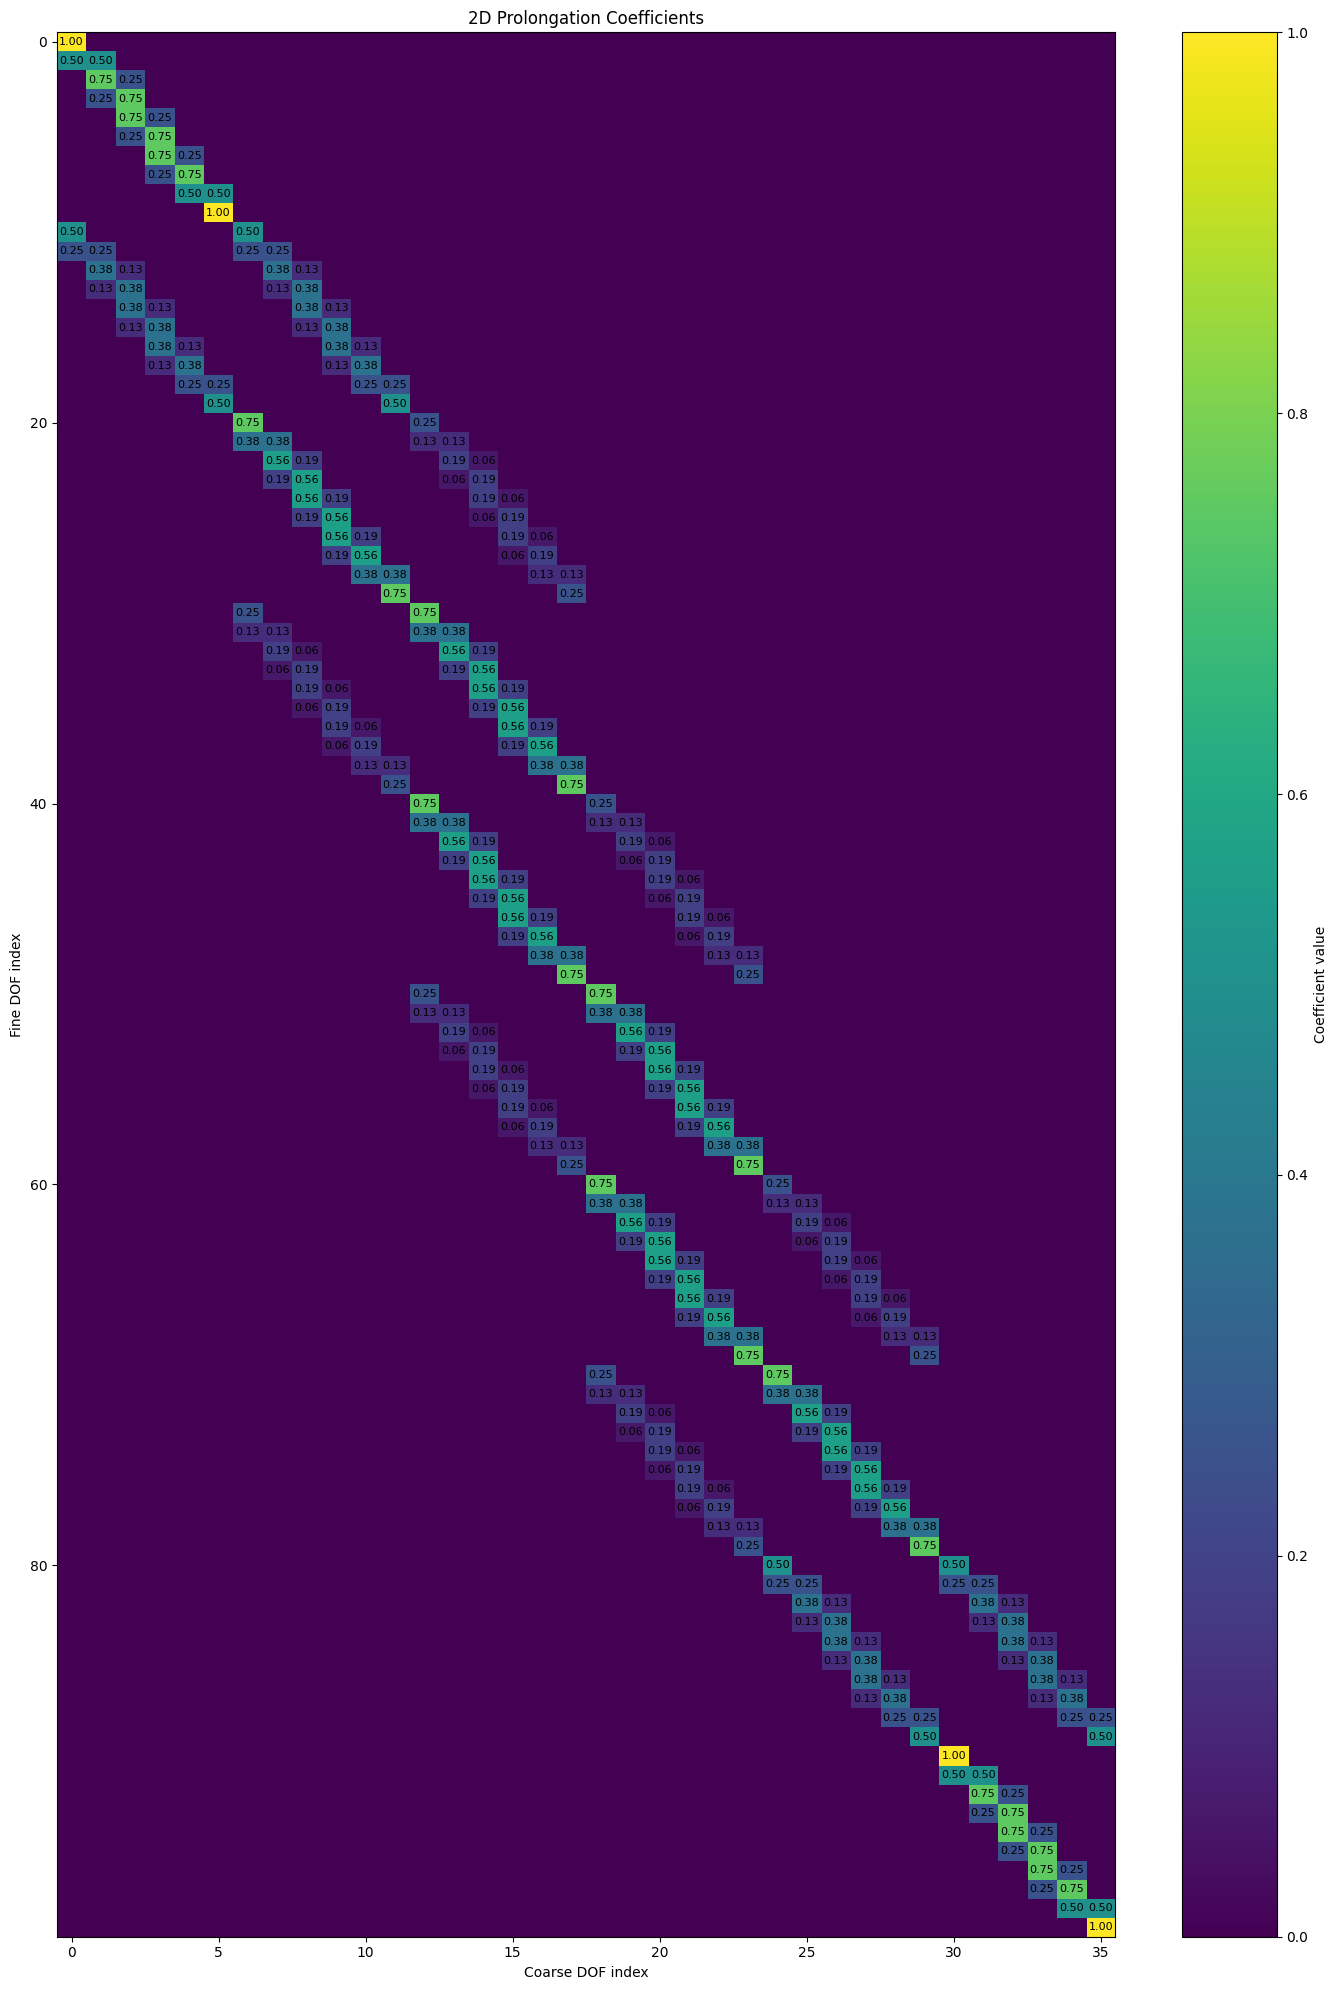

In [12]:
# now use kronecker product of 1d prolongation / restriction matrix to construct the 2d prolongation stencil..

R_twod = np.zeros((n_coarse**2, n_fine**2))

for inode_c in range(n_coarse**2):
    ix_c, iy_c = inode_c % n_coarse, inode_c // n_coarse

    for inode_f in range(n_fine**2):
        ix_f, iy_f = inode_f % n_fine, inode_f // n_fine

        R_twod[inode_c, inode_f] = R[ix_c, ix_f] * R[iy_c, iy_f]

plt.figure(figsize=(14, 20))
plt.imshow(R_twod.T, aspect="auto")
plt.colorbar(label="Coefficient value")
plt.xlabel("Coarse DOF index")
plt.ylabel("Fine DOF index")
plt.title("2D Prolongation Coefficients")

for i in range(R_twod.shape[0]):
    for j in range(R_twod.shape[1]):
        if abs(R_twod[i, j]) > 1e-12:
            plt.text(i, j, f"{R_twod[i, j]:.2f}",
                     ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

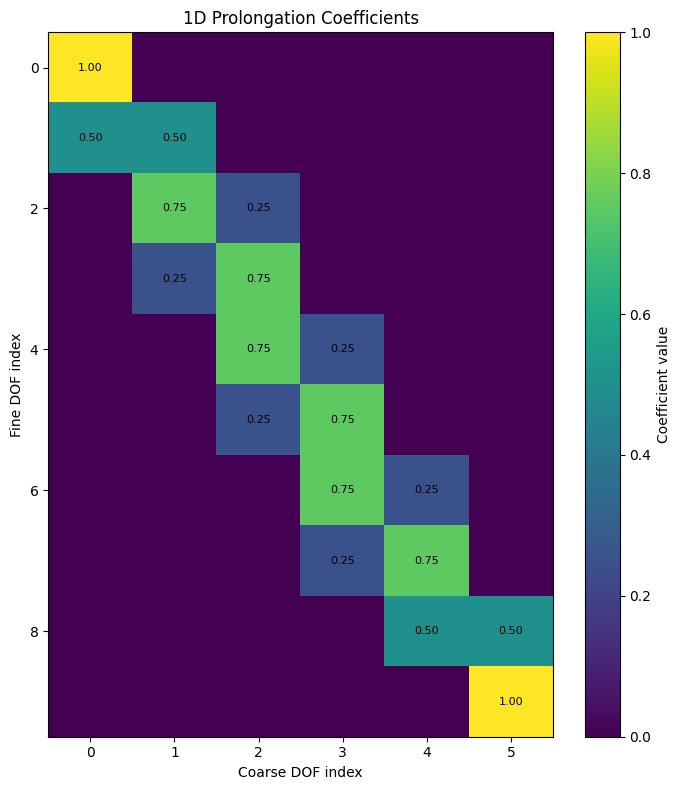

In [ ]:
# easier way to reconstruct the 1d prolongation pattern for inside a new structured prolongation class


# nxe_f = 2
nxe_f = 8
# nxe_f = 16

p = 2
nxe_c = nxe_f // 2
n_fine = nxe_f + p
n_coarse = nxe_c + p

# ===============================================
# now try to reconstruct fine basis from this
# ===============================================

# restriction operator or P^T global
P = np.zeros((n_fine, n_coarse))
counts = 1e-14 * np.ones((n_coarse, n_fine))



for inode_f in range(nxe_f+p):

    # 2 connected coarse nodes each time
    even = inode_f % 2 == 0
    inode_c = inode_f // 2

    # we can use ternary operators to make this more GPU friendly!

    if even:
        P[inode_f, inode_c] = 0.75
        P[inode_f, inode_c+1] = 0.25
    else: # odd
        P[inode_f, inode_c] = 0.25
        P[inode_f, inode_c+1] = 0.75

    if inode_c == 0:
        P[inode_f, inode_c] += 0.25
        P[inode_f, inode_c+1] -= 0.25
    elif (inode_c+1) == (nxe_c+p-1): # coarse right boundary
        P[inode_f, inode_c] -= 0.25
        P[inode_f, inode_c+1] += 0.25

# last = (nxe_c+p-1)
# print(f"{last=}")

R = P.T

plt.figure(figsize=(7, 8))
plt.imshow(R.T, aspect="auto")
plt.colorbar(label="Coefficient value")
plt.xlabel("Coarse DOF index")
plt.ylabel("Fine DOF index")
plt.title("1D Prolongation Coefficients")

for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        if abs(R[i, j]) > 1e-12:
            plt.text(i, j, f"{R[i, j]:.2f}",
                     ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()
